# Lab 5: LSTM for Text Classification

## Problem Statement
Build an LSTM model to classify text into categories (e.g., positive vs negative sentiment) using the IMDB dataset.

In [1]:
import numpy as np
from tensorflow.keras.datasets import imdb
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense
from tensorflow.keras.preprocessing.sequence import pad_sequences
import matplotlib.pyplot as plt

In [2]:
vocab_size = 10000  # top 10k words

(X_train, y_train), (X_test, y_test) = imdb.load_data(num_words=vocab_size)

print(f"Training samples: {len(X_train)}, Test samples: {len(X_test)}")
print(f"Sample review (encoded): {X_train[0][:10]}...")
print(f"Label: {y_train[0]}")

/Users/prateekrai/Desktop/DL/venv/lib/python3.13/site-packages/numpy/lib/_format_impl.py:838: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  array = pickle.load(fp, **pickle_kwargs)


Training samples: 25000, Test samples: 25000
Sample review (encoded): [1, 14, 22, 16, 43, 530, 973, 1622, 1385, 65]...
Label: 1


In [3]:
max_len = 200  # max words per review

X_train = pad_sequences(X_train, maxlen=max_len)
X_test = pad_sequences(X_test, maxlen=max_len)

print(f"X_train shape: {X_train.shape}, X_test shape: {X_test.shape}")

X_train shape: (25000, 200), X_test shape: (25000, 200)


In [4]:
model = Sequential()

# Convert words into dense vectors
model.add(Embedding(input_dim=vocab_size, output_dim=128, input_length=max_len))

# LSTM layer
model.add(LSTM(64))

# Output layer
model.add(Dense(1, activation='sigmoid'))

model.summary()

/Users/prateekrai/Desktop/DL/venv/lib/python3.13/site-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [5]:
model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

In [6]:
history = model.fit(
    X_train, y_train,
    epochs=3,
    batch_size=64,
    validation_split=0.2
)

Epoch 1/3
313/313 ━━━━━━━━━━━━━━━━━━━━ 11s 34ms/step - accuracy: 0.8063 - loss: 0.4161 - val_accuracy: 0.8642 - val_loss: 0.3199
Epoch 2/3
313/313 ━━━━━━━━━━━━━━━━━━━━ 10s 33ms/step - accuracy: 0.9104 - loss: 0.2360 - val_accuracy: 0.8534 - val_loss: 0.3268
Epoch 3/3
313/313 ━━━━━━━━━━━━━━━━━━━━ 10s 33ms/step - accuracy: 0.9266 - loss: 0.1925 - val_accuracy: 0.8614 - val_loss: 0.3345


In [10]:
loss, accuracy = model.evaluate(X_test, y_test)
print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")

782/782 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.8514 - loss: 0.3548
Test Loss: 0.3548
Test Accuracy: 0.8514


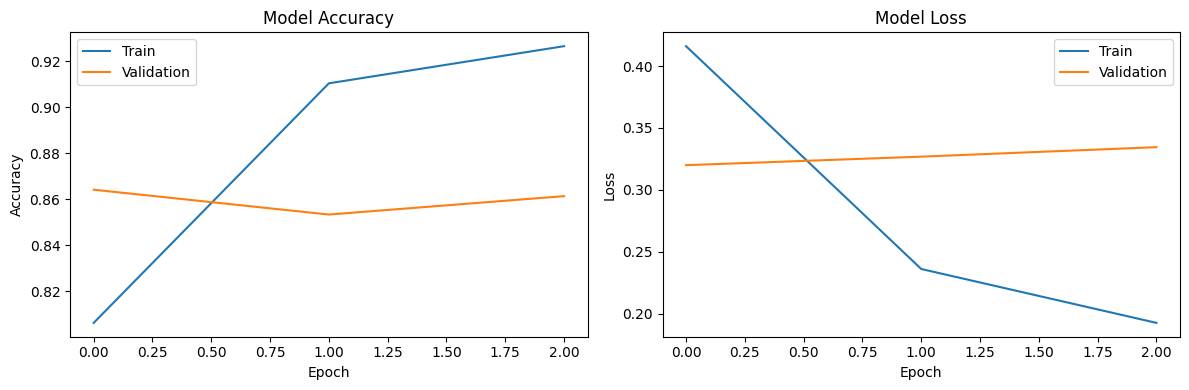

In [9]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Validation')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Validation')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

## Explanation

- **Embedding Layer**: Converts words into dense vectors for better representation.
- **LSTM Layer**: Captures sequential dependencies and long-term context in text.
- **Dense Output**: Sigmoid activation for binary classification (positive/negative).

## Why LSTM Works Better

LSTM remembers long-term dependencies, avoids vanishing gradients, and captures context in sentences, making it superior to simple RNNs for text tasks.

## Conclusion

The LSTM model effectively captures sequential dependencies in text data, achieving good classification performance on sentiment analysis. It is well-suited for NLP tasks.